# Disproportionality Analysis — FEARS Pipeline Output
## PRR, ROR, and EBGM Signal Detection

Based on methodology from:
- **Evans et al. (2001)** — PRR
- **van Puijenbroek et al. (2002)** — ROR
- **DuMouchel (1999)** — MGPS / EBGM

**Data:** Final pipeline output (adult + pediatric cohorts)
**Subgroups:** Adult, Pediatric (overall), NICHD age bands

## 0. Setup

In [113]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from IPython.display import display, Markdown
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.figsize": (12, 5), "figure.dpi": 120, "font.size": 11})

## 1. Load Data

In [114]:
DATA_ROOT = Path("../data/output")

adult = pl.read_parquet(DATA_ROOT / "Adult" / "patient_report_reporter_drug_reaction_full_data.parquet")
pediatric = pl.read_parquet(DATA_ROOT / "Pediatric" / "patient_report_reporter_drug_reaction_full_data.parquet")

print(f"Adult:      {adult.height:>12,} rows | {adult['safetyreportid'].n_unique():>10,} unique reports")
print(f"Pediatric:  {pediatric.height:>12,} rows | {pediatric['safetyreportid'].n_unique():>10,} unique reports")
print(f"Total:      {adult.height + pediatric.height:>12,} rows")

Adult:        17,813,299 rows |  2,506,379 unique reports
Pediatric:       953,037 rows |    221,182 unique reports
Total:        18,766,336 rows


## 2. Core Functions

### 2.1 Precompute Pair Counts

สร้าง lookup table ครั้งเดียว แล้วใช้ O(1) ต่อ pair — เร็วกว่า filter ซ้ำหลายรอบ

In [115]:
def precompute_pair_counts(df: pl.DataFrame, drug_col: str, event_col: str) -> tuple:
    """Precompute all drug-event pair counts in one pass.

    Returns:
        pair_lookup: dict {(drug, event): count}
        drug_totals: dict {drug: total_events}
        event_totals: dict {event: total_drugs}
        N: total drug-event pairs
    """
    pairs = df.select(
        pl.col(drug_col).alias("drug"),
        pl.col(event_col).alias("event"),
    )

    N = pairs.height

    pair_counts = pairs.group_by(["drug", "event"]).agg(pl.len().alias("count"))
    drug_totals = dict(pairs.group_by("drug").agg(pl.len().alias("total")).iter_rows())
    event_totals = dict(pairs.group_by("event").agg(pl.len().alias("total")).iter_rows())

    pair_lookup = {}
    for row in pair_counts.iter_rows(named=True):
        pair_lookup[(row["drug"], row["event"])] = row["count"]

    return pair_lookup, drug_totals, event_totals, N


def get_2x2(pair_lookup, drug_totals, event_totals, N, target_drug, target_event):
    """Get 2x2 table values from precomputed counts (O(1) lookup).

    Returns: a, b, c, d
    """
    a = pair_lookup.get((target_drug, target_event), 0)
    b = drug_totals.get(target_drug, 0) - a      # drug + other events
    c = event_totals.get(target_event, 0) - a     # other drugs + this event
    d = N - a - b - c                             # other drugs + other events
    return a, b, c, d

print("Defined: precompute_pair_counts(), get_2x2()")

Defined: precompute_pair_counts(), get_2x2()


### 2.2 PRR (Proportional Reporting Ratio)

$$PRR = \frac{a / (a+b)}{c / (c+d)}$$

$$SE(\ln PRR) = \sqrt{\frac{1}{a} - \frac{1}{a+b} + \frac{1}{c} - \frac{1}{c+d}}$$

Signal: 95% CI lower limit > 1

In [116]:
def compute_prr(a, b, c, d):
    """PRR with 95% CI and chi-squared.

    Formula (from image):
        PRR = (a/(a+b)) / (c/(c+d))
        SE(lnPRR) = sqrt(1/a - 1/(a+b) + 1/c - 1/(c+d))
        95% CI = exp(ln(PRR) +/- 1.96 * SE)
    Signal: 95% CI lower limit > 1
    """
    if a == 0 or c == 0 or (a + b) == 0 or (c + d) == 0:
        return {"PRR": np.nan, "PRR_lower": np.nan, "PRR_upper": np.nan,
                "chi2": np.nan, "PRR_signal": False}

    prr = (a / (a + b)) / (c / (c + d))

    se = np.sqrt(1/a - 1/(a+b) + 1/c - 1/(c+d))
    ci_lo = np.exp(np.log(prr) - 1.96 * se)
    ci_hi = np.exp(np.log(prr) + 1.96 * se)

    table = np.array([[a, b], [c, d]])
    chi2_val, _, _, _ = chi2_contingency(table, correction=False)

    signal = ci_lo > 1

    return {
        "PRR": round(prr, 2),
        "PRR_lower": round(ci_lo, 2),
        "PRR_upper": round(ci_hi, 2),
        "chi2": round(chi2_val, 2),
        "PRR_signal": signal,
    }

print("Defined: compute_prr()")

Defined: compute_prr()


### 2.3 ROR (Reporting Odds Ratio)

$$ROR = \frac{a/c}{b/d} = \frac{a \times d}{b \times c}$$

$$SE(\ln ROR) = \sqrt{\frac{1}{a} + \frac{1}{b} + \frac{1}{c} + \frac{1}{d}}$$

Signal: 95% CI lower limit > 1

In [117]:
def compute_ror(a, b, c, d):
    """ROR with 95% CI.

    Formula (from image):
        ROR = (a/c) / (b/d) = (a*d) / (b*c)
        SE(lnROR) = sqrt(1/a + 1/b + 1/c + 1/d)
        95% CI = exp(ln(ROR) +/- 1.96 * SE)
    Signal: 95% CI lower limit > 1
    """
    if a == 0 or b == 0 or c == 0 or d == 0:
        return {"ROR": np.nan, "ROR_lower": np.nan, "ROR_upper": np.nan,
                "ROR_signal": False}

    ror = (a * d) / (b * c)

    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    ci_lo = np.exp(np.log(ror) - 1.96 * se)
    ci_hi = np.exp(np.log(ror) + 1.96 * se)

    signal = ci_lo > 1

    return {
        "ROR": round(ror, 2),
        "ROR_lower": round(ci_lo, 2),
        "ROR_upper": round(ci_hi, 2),
        "ROR_signal": signal,
    }

print("Defined: compute_ror()")

Defined: compute_ror()


### 2.4 EBGM (Empirical Bayesian Geometric Mean)

Frequentist observed/expected ratio with log-normal CI:

$$EBGM = \frac{a \times (a+b+c+d)}{(a+c) \times (a+b)}$$

$$SE(\ln EBGM) = \sqrt{\frac{1}{a} + \frac{1}{b} + \frac{1}{c} + \frac{1}{d}}$$

Signal: EBGM05 (lower 95% CI) > 2

In [118]:
def compute_ebgm(a, b, c, d):
    """EBGM with 95% CI (frequentist, from image).

    Formula (from image):
        EBGM = a(a+b+c+d) / ((a+c)(a+b))
        SE(lnEBGM) = sqrt(1/a + 1/b + 1/c + 1/d)
        95% CI = exp(ln(EBGM) +/- 1.96 * SE)
    Signal: EBGM05 (lower 95% CI) > 2
    """
    N = a + b + c + d

    if a == 0 or b == 0 or c == 0 or d == 0 or N == 0:
        return {"EBGM": np.nan, "EBGM05": np.nan, "EBGM95": np.nan,
                "EBGM_signal": False}

    ebgm = (a * N) / ((a + c) * (a + b))

    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    ebgm05 = np.exp(np.log(ebgm) - 1.96 * se)  # lower 95% CI
    ebgm95 = np.exp(np.log(ebgm) + 1.96 * se)  # upper 95% CI

    signal = ebgm05 > 2

    return {
        "EBGM": round(ebgm, 2),
        "EBGM05": round(ebgm05, 2),
        "EBGM95": round(ebgm95, 2),
        "EBGM_signal": signal,
    }

print("Defined: compute_ebgm()")

Defined: compute_ebgm()


### 2.5 Batch Computation

รวม PRR + ROR + EBGM เข้าด้วยกัน คำนวณทีเดียวหลาย pairs

In [119]:
def compute_signals_batch(df, drug_col, event_col, pairs, label=""):
    """Compute PRR, ROR, EBGM for a list of (drug, event) pairs.

    Precomputes pair counts once, then O(1) per pair.
    """
    pair_lookup, drug_totals, event_totals, N = precompute_pair_counts(df, drug_col, event_col)

    results = []
    for drug, event in pairs:
        a, b, c, d = get_2x2(pair_lookup, drug_totals, event_totals, N, drug, event)
        E = ((a + b) * (a + c)) / N if N > 0 else 0

        prr = compute_prr(a, b, c, d)
        ror = compute_ror(a, b, c, d)
        ebgm = compute_ebgm(a, b, c, d)

        results.append({
            "drug": drug, "event": event,
            "N_total": N, "a": a, "b": b, "c": c, "d": d,
            "E (expected)": round(E, 2),
            **prr, **ror, **ebgm,
        })

    return pl.DataFrame(results).cast({
        "PRR_signal": pl.Boolean,
        "ROR_signal": pl.Boolean,
        "EBGM_signal": pl.Boolean,
    }, strict=False)


def _fmt(val, lo, hi):
    """Format value with 95% CI: '12.34 (10.00, 14.50)'"""
    if val is None or np.isnan(val):
        return ""
    if lo is None or np.isnan(lo):
        return f"{val:.2f}"
    return f"{val:.2f} ({lo:.2f}, {hi:.2f})"


def _fmt_ebgm(val, lo, hi):
    """Format EBGM with 95% CI: '12.34 (10.00, 14.50)'"""
    if val is None or np.isnan(val):
        return ""
    if lo is None or np.isnan(lo):
        return f"{val:.2f}"
    return f"{val:.2f} ({lo:.2f}, {hi:.2f})"


def _signal_icon(prr_sig, ror_sig, ebgm_sig):
    """Show signal status per method: 1 = signal, 0 = non-signal."""
    p = 1 if prr_sig else 0
    r = 1 if ror_sig else 0
    e = 1 if ebgm_sig else 0
    return f"{p}/{r}/{e}"


def format_signal_table(signals_df):
    """Format signals into compact publication-style table.

    Signal column shows PRR/ROR/EBGM as +/- (e.g. +/+/+ = all agree).
    """
    rows = []
    for r in signals_df.iter_rows(named=True):
        rows.append({
            "Drug": r["drug"],
            "Event": r["event"],
            "a": r["a"],
            "b": r["b"],
            "c": r["c"],
            "d": r["d"],
            "Expected (E)": round(r["E (expected)"], 2),
            "ROR (95% CI)": _fmt(r["ROR"], r["ROR_lower"], r["ROR_upper"]),
            "PRR (95% CI)": _fmt(r["PRR"], r["PRR_lower"], r["PRR_upper"]),
            "chi2": round(r["chi2"], 2) if r["chi2"] is not None and not np.isnan(r["chi2"]) else None,
            "EBGM (95% CI)": _fmt_ebgm(r["EBGM"], r["EBGM05"], r["EBGM95"]),
            "Signal (P/R/E)": _signal_icon(r["PRR_signal"], r["ROR_signal"], r["EBGM_signal"]),
        })
    return pl.DataFrame(rows).sort("a", descending=True)


def format_signal_table_by_ror(signals_df):
    """Format signals sorted by ROR descending (nulls last)."""
    sorted_df = signals_df.sort("ROR", descending=True, nulls_last=True)
    
    rows = []
    for r in sorted_df.iter_rows(named=True):
        rows.append({
            "Drug": r["drug"],
            "Event": r["event"],
            "a": r["a"],
            "b": r["b"],
            "c": r["c"],
            "d": r["d"],
            "Expected (E)": round(r["E (expected)"], 2),
            "ROR (95% CI)": _fmt(r["ROR"], r["ROR_lower"], r["ROR_upper"]),
            "PRR (95% CI)": _fmt(r["PRR"], r["PRR_lower"], r["PRR_upper"]),
            "chi2": round(r["chi2"], 2) if r["chi2"] is not None and not np.isnan(r["chi2"]) else None,
            "EBGM (95% CI)": _fmt_ebgm(r["EBGM"], r["EBGM05"], r["EBGM95"]),
            "Signal (P/R/E)": _signal_icon(r["PRR_signal"], r["ROR_signal"], r["EBGM_signal"]),
        })
    return pl.DataFrame(rows)

print("Defined: compute_signals_batch(), _fmt(), _fmt_ebgm(), _signal_icon(), format_signal_table()")

Defined: compute_signals_batch(), _fmt(), _fmt_ebgm(), _signal_icon(), format_signal_table()


## 3. Compute All Drug-Event Pairs

Compute PRR, ROR, EBGM for **every unique (drug, event) pair** in each cohort, then show Top 50 sorted by ROR.

In [120]:
def get_all_drug_event_pairs(df):
    """Get ALL unique (drug, event) pairs in the dataset."""
    pairs = (
        df.select("medicinal_product", "reaction_meddrapt")
        .unique()
        .filter(
            pl.col("medicinal_product").is_not_null()
            & pl.col("reaction_meddrapt").is_not_null()
        )
    )
    return list(zip(
        pairs["medicinal_product"].to_list(),
        pairs["reaction_meddrapt"].to_list(),
    ))

adult_pairs = get_all_drug_event_pairs(adult)
pediatric_pairs = get_all_drug_event_pairs(pediatric)

print(f"Adult pairs (all):     {len(adult_pairs):,}")
print(f"Pediatric pairs (all): {len(pediatric_pairs):,}")

Adult pairs (all):     1,187,842
Pediatric pairs (all): 224,741


## 4. Top 50 Signals (by ROR)

### 4.1 Adult Cohort

In [121]:
print("Computing Adult signals (all pairs)...")
adult_signals = compute_signals_batch(adult, "medicinal_product", "reaction_meddrapt", adult_pairs, label="Adult")
print(f"Done: {adult_signals.height:,} pairs computed")

display(Markdown("**Top 50 Adult Signals (sorted by ROR, descending):**"))
display(format_signal_table_by_ror(adult_signals).head(50))

Computing Adult signals (all pairs)...
Done: 1,187,842 pairs computed


**Top 50 Adult Signals (sorted by ROR, descending):**

Drug,Event,a,b,c,d,Expected (E),ROR (95% CI),PRR (95% CI),chi2,EBGM (95% CI),Signal (P/R/E)
str,str,i64,i64,i64,i64,f64,str,str,f64,str,str
"""CLOVAZAM""","""Bradycardia""",1,0,50384,17762914,0.0,"""""","""353.55 (350.48, 356.65)""",352.54,"""""","""1/0/0"""
"""BEXAROTENE 75 MG""","""Lymphadenopathy""",1,0,21198,17792100,0.0,"""""","""840.33 (829.10, 851.71)""",839.29,"""""","""1/0/0"""
"""OXYNORM DISPERSA""","""Delirium""",2,0,62704,17750593,0.01,"""""","""284.09 (281.87, 286.31)""",566.15,"""""","""1/0/0"""
"""SKINMEDICA TOTAL DEFENSE + REP…","""Polyp""",1,0,3401,17809897,0.0,"""""","""5237.66 (5064.57, 5416.67)""",5235.13,"""""","""1/0/0"""
"""PROPOFOL KABI - FRESENIUS KABI…","""Angioedema""",1,0,39021,17774277,0.0,"""""","""456.51 (452.00, 461.05)""",455.49,"""""","""1/0/0"""
…,…,…,…,…,…,…,…,…,…,…,…
"""GONIOSOFT""","""Endophthalmitis""",1,0,4601,17808697,0.0,"""""","""3871.61 (3761.36, 3985.10)""",3869.77,"""""","""1/0/0"""
"""HUMIRA""","""Fetishism""",1,198200,0,17615098,0.01,"""""","""""",null,"""""","""0/0/0"""
"""BALZIVA""","""Rash""",1,0,363906,17449392,0.02,"""""","""48.95 (48.79, 49.11)""",47.95,"""""","""1/0/0"""


### 4.2 Pediatric Cohort — Top 50 Signals

In [122]:
print("Computing Pediatric signals (all pairs)...")
ped_signals = compute_signals_batch(pediatric, "medicinal_product", "reaction_meddrapt", pediatric_pairs, label="Pediatric")
print(f"Done: {ped_signals.height:,} pairs computed")

display(Markdown("**Top 50 Pediatric Signals (sorted by ROR, descending):**"))
display(format_signal_table_by_ror(ped_signals).head(50))

Computing Pediatric signals (all pairs)...
Done: 224,741 pairs computed


**Top 50 Pediatric Signals (sorted by ROR, descending):**

Drug,Event,a,b,c,d,Expected (E),ROR (95% CI),PRR (95% CI),chi2,EBGM (95% CI),Signal (P/R/E)
str,str,i64,i64,i64,i64,f64,str,str,f64,str,str
"""LAMITRIGINE AUROBINDO DISPERSI…","""Epilepsy""",1,0,4355,948681,0.0,"""""","""218.84 (212.45, 225.42)""",217.79,"""""","""1/0/0"""
"""AIRDUO RESPICLICK""","""Nightmare""",1,0,642,952394,0.0,"""""","""1484.48 (1374.01, 1603.83)""",1481.17,"""""","""1/0/0"""
"""FURSEMID""","""Vomiting""",2,0,31379,921656,0.07,"""""","""30.37 (30.04, 30.70)""",58.74,"""""","""1/0/0"""
"""5 FU""","""Haemorrhage""",1,0,4336,948700,0.0,"""""","""219.80 (213.36, 226.42)""",218.75,"""""","""1/0/0"""
"""TIRATAM""","""Blister""",1,0,1270,951766,0.0,"""""","""750.42 (710.29, 792.82)""",748.83,"""""","""1/0/0"""
…,…,…,…,…,…,…,…,…,…,…,…
"""DEXTROAMP-AMPHET ER 20MG CAPS …","""Vomiting""",1,0,31380,921656,0.03,"""""","""30.37 (30.04, 30.70)""",29.37,"""""","""1/0/0"""
"""DESMETHYLDIAZEPAM""","""Overdose""",1,0,12172,940864,0.01,"""""","""78.30 (76.93, 79.69)""",77.29,"""""","""1/0/0"""
"""RESTAMIN""","""Erythema""",1,0,7814,945222,0.01,"""""","""121.97 (119.30, 124.69)""",120.95,"""""","""1/0/0"""


## 5. Subgroup Analysis — NICHD Age Bands

คำนวณ signals ใหม่ภายในแต่ละ age band ของ pediatric:
- infancy (0-11 months)
- toddler (1 year)
- early_childhood (2-5 years)
- middle_childhood (6-11 years)
- early_adolescence (12-17 years)
- late_adolescence (18-21 years)

In [123]:
nichd_bands = ["infancy", "toddler", "early_childhood", "middle_childhood",
               "early_adolescence", "late_adolescence"]

# Use top 30 pediatric pairs by ROR for subgroup analysis
top_ped_by_ror = ped_signals.sort('ROR', descending=True, nulls_last=True).head(30)
top_ped_pairs = list(zip(top_ped_by_ror['drug'].to_list(), top_ped_by_ror['event'].to_list()))
subgroup_df = pl.DataFrame()

if "nichd" in pediatric.columns:
    subgroup_dfs = []
    for band in nichd_bands:
        sub_df = pediatric.filter(pl.col("nichd") == band)
        if sub_df.height < 10:
            print(f"  {band}: {sub_df.height} rows — skipped")
            continue

        print(f"  {band}: {sub_df.height:,} rows")
        band_signals = compute_signals_batch(
            sub_df, "medicinal_product", "reaction_meddrapt", top_ped_pairs
        )
        band_signals = band_signals.with_columns(
            pl.lit(band).alias("nichd_band"),
            pl.lit(sub_df.height).alias("subgroup_n"),
        )
        subgroup_dfs.append(band_signals)

    if subgroup_dfs:
        subgroup_df = pl.concat(subgroup_dfs, how="vertical_relaxed")
        print(f"\nTotal: {subgroup_df.height} rows across {len(subgroup_dfs)} bands")
else:
    print("nichd column not available")

  infancy: 64,675 rows
  toddler: 32,239 rows
  early_childhood: 136,785 rows
  middle_childhood: 173,351 rows
  early_adolescence: 317,459 rows
  late_adolescence: 228,528 rows

Total: 180 rows across 6 bands


In [124]:
# Display subgroup results (a >= 3 only) — compact format
if subgroup_df.height > 0:
    sub_rows = []
    for r in subgroup_df.filter(pl.col("a") >= 3).iter_rows(named=True):
        sub_rows.append({
            "NICHD Band": r["nichd_band"],
            "N (subgroup)": r["subgroup_n"],
            "Drug": r["drug"],
            "Event": r["event"],
            "a": r["a"],
            "b": r["b"],
            "c": r["c"],
            "d": r["d"],
            "ROR (95% CI)": _fmt(r["ROR"], r["ROR_lower"], r["ROR_upper"]),
            "PRR (95% CI)": _fmt(r["PRR"], r["PRR_lower"], r["PRR_upper"]),
            "chi2": round(r["chi2"], 2) if r.get("chi2") is not None and not np.isnan(r.get("chi2", float("nan"))) else None,
            "EBGM (95% CI)": _fmt_ebgm(r["EBGM"], r["EBGM05"], r["EBGM95"]),
            "Signal (P/R/E)": _signal_icon(r["PRR_signal"], r["ROR_signal"], r["EBGM_signal"]),
        })
    sub_table = pl.DataFrame(sub_rows).sort(["Drug", "Event", "NICHD Band"])
    display(Markdown(f"**Pediatric Subgroup Signals (a >= 3): {sub_table.height} rows**"))
    display(sub_table)
else:
    print("No subgroup data")

**Pediatric Subgroup Signals (a >= 3): 2 rows**

NICHD Band,N (subgroup),Drug,Event,a,b,c,d,ROR (95% CI),PRR (95% CI),chi2,EBGM (95% CI),Signal (P/R/E)
str,i64,str,str,i64,i64,i64,i64,str,str,f64,str,str
"""infancy""",64675,"""APROVEL""","""Microcephaly""",4,0,368,64303,"""""","""175.74 (158.71, 194.58)""",691.47,"""""","""1/0/0"""
"""late_adolescence""",228528,"""FELDENE""","""Sopor""",3,0,1186,227339,"""""","""192.69 (182.05, 203.94)""",573.61,"""""","""1/0/0"""


## 6. Cross-Cohort Comparison

เปรียบเทียบ drug-event pairs **เดียวกัน** ระหว่าง Adult, Pediatric, และทุก NICHD subgroup

In [125]:
# Find common drug-event pairs in both cohorts
common_drugs = set(adult["medicinal_product"].unique().to_list()) & set(pediatric["medicinal_product"].unique().to_list())
common_events = set(adult["reaction_meddrapt"].unique().to_list()) & set(pediatric["reaction_meddrapt"].unique().to_list())

common_pairs = [
    (drug, event) for drug, event in adult_pairs
    if drug in common_drugs and event in common_events
][:20]

print(f"Common pairs for comparison: {len(common_pairs)}")

Common pairs for comparison: 20


In [126]:
# Compute for Adult
print("  Adult...")
cross_adult = compute_signals_batch(
    adult, "medicinal_product", "reaction_meddrapt", common_pairs
).with_columns(pl.lit("Adult").alias("cohort"))

# Compute for Pediatric overall
print("  Pediatric...")
cross_ped = compute_signals_batch(
    pediatric, "medicinal_product", "reaction_meddrapt", common_pairs
).with_columns(pl.lit("Pediatric").alias("cohort"))

cross_parts = [cross_adult, cross_ped]

# Compute for each NICHD subgroup
if "nichd" in pediatric.columns:
    for band in nichd_bands:
        sub_df = pediatric.filter(pl.col("nichd") == band)
        if sub_df.height >= 10:
            print(f"  Ped-{band}...")
            cross_sub = compute_signals_batch(
                sub_df, "medicinal_product", "reaction_meddrapt", common_pairs
            ).with_columns(pl.lit(f"Ped-{band}").alias("cohort"))
            cross_parts.append(cross_sub)

cross_df = pl.concat(cross_parts, how="vertical_relaxed")
print(f"\nTotal: {cross_df.height} rows")

  Adult...
  Pediatric...
  Ped-infancy...
  Ped-toddler...
  Ped-early_childhood...
  Ped-middle_childhood...
  Ped-early_adolescence...
  Ped-late_adolescence...

Total: 160 rows


In [127]:
# Display cross-cohort comparison — compact format
display(Markdown("### Cross-Cohort Signal Comparison"))

cross_rows = []
for r in cross_df.iter_rows(named=True):
    cross_rows.append({
        "Cohort": r["cohort"],
        "Drug": r["drug"],
        "Event": r["event"],
        "a": r["a"],
            "b": r["b"],
            "c": r["c"],
            "d": r["d"],
        "Expected (E)": round(r["E (expected)"], 2),
        "ROR (95% CI)": _fmt(r["ROR"], r["ROR_lower"], r["ROR_upper"]),
        "PRR (95% CI)": _fmt(r["PRR"], r["PRR_lower"], r["PRR_upper"]),
        "chi2": round(r["chi2"], 2) if r.get("chi2") is not None and not np.isnan(r.get("chi2", float("nan"))) else None,
        "EBGM (95% CI)": _fmt_ebgm(r["EBGM"], r["EBGM05"], r["EBGM95"]),
        "Signal (P/R/E)": _signal_icon(r["PRR_signal"], r["ROR_signal"], r["EBGM_signal"]),
    })
cross_table = pl.DataFrame(cross_rows).sort(["Drug", "Event", "Cohort"])
display(cross_table)

### Cross-Cohort Signal Comparison

Cohort,Drug,Event,a,b,c,d,Expected (E),ROR (95% CI),PRR (95% CI),chi2,EBGM (95% CI),Signal (P/R/E)
str,str,str,i64,i64,i64,i64,f64,str,str,f64,str,str
"""Adult""","""AMLODIPINE""","""Lymphadenitis""",2,40864,2169,17770264,4.98,"""0.40 (0.10, 1.60)""","""0.40 (0.10, 1.60)""",1.79,"""0.40 (0.10, 1.61)""","""0/0/0"""
"""Ped-early_adolescence""","""AMLODIPINE""","""Lymphadenitis""",0,1470,95,315894,0.44,"""""","""""",null,"""""","""0/0/0"""
"""Ped-early_childhood""","""AMLODIPINE""","""Lymphadenitis""",0,88,70,136627,0.05,"""""","""""",null,"""""","""0/0/0"""
"""Ped-infancy""","""AMLODIPINE""","""Lymphadenitis""",0,73,50,64552,0.06,"""""","""""",null,"""""","""0/0/0"""
"""Ped-late_adolescence""","""AMLODIPINE""","""Lymphadenitis""",0,654,94,227780,0.27,"""""","""""",null,"""""","""0/0/0"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""Ped-infancy""","""ZOLPIDEM""","""Shock""",0,51,146,64478,0.12,"""""","""""",null,"""""","""0/0/0"""
"""Ped-late_adolescence""","""ZOLPIDEM""","""Shock""",1,314,573,227640,0.79,"""1.27 (0.18, 9.03)""","""1.26 (0.18, 8.96)""",0.06,"""1.26 (0.18, 9.02)""","""0/0/0"""
"""Ped-middle_childhood""","""ZOLPIDEM""","""Shock""",0,11,366,172974,0.02,"""""","""""",null,"""""","""0/0/0"""


## 7. Visualization — PRR Comparison

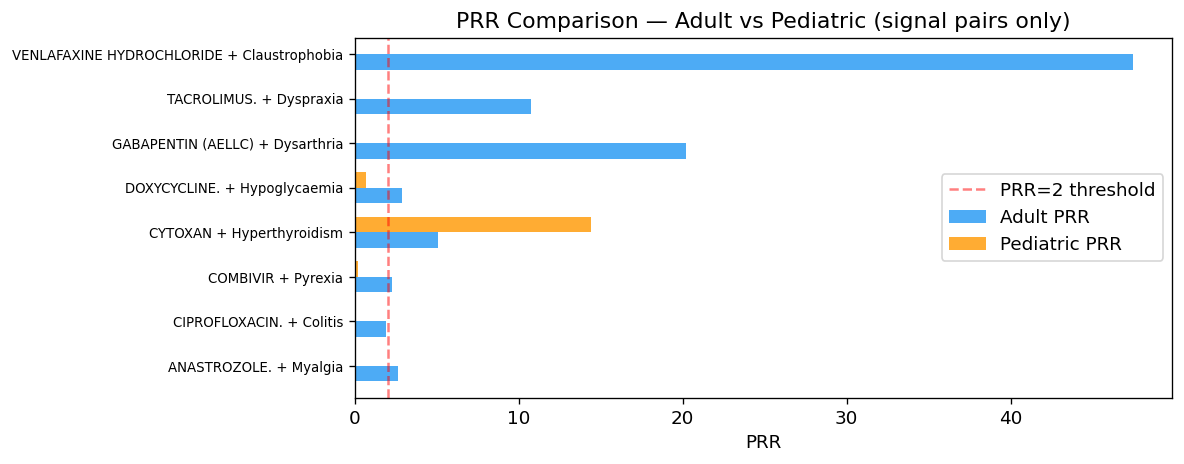

In [128]:
if cross_df.height > 0:
    cross_with_label = cross_df.with_columns(
        (pl.col("drug") + " + " + pl.col("event")).alias("pair")
    )

    # Filter to signal pairs only
    has_signal = (
        cross_with_label
        .group_by("pair")
        .agg(pl.col("PRR_signal").any().alias("any_signal"))
        .filter(pl.col("any_signal"))["pair"].to_list()
    )

    signal_pairs = cross_with_label.filter(pl.col("pair").is_in(has_signal))

    if signal_pairs.height > 0:
        pivot_data = (
            signal_pairs
            .filter(pl.col("cohort").is_in(["Adult", "Pediatric"]))
            .select(["pair", "cohort", "PRR"])
            .pivot(on="cohort", index="pair", values="PRR")
            .sort("pair")
        )

        if pivot_data.height > 0:
            fig, ax = plt.subplots(figsize=(10, max(4, pivot_data.height * 0.4)))
            pairs_list = pivot_data["pair"].to_list()
            adult_prr = [v if v is not None else 0 for v in pivot_data.get_column("Adult").to_list()]
            ped_prr = [v if v is not None else 0 for v in pivot_data.get_column("Pediatric").to_list()]

            y = np.arange(len(pairs_list))
            h = 0.35
            ax.barh(y - h/2, adult_prr, h, label="Adult PRR", color="#2196F3", alpha=0.8)
            ax.barh(y + h/2, ped_prr, h, label="Pediatric PRR", color="#FF9800", alpha=0.8)
            ax.axvline(x=2, color="red", linestyle="--", alpha=0.5, label="PRR=2 threshold")
            ax.set_yticks(y)
            ax.set_yticklabels(pairs_list, fontsize=8)
            ax.set_xlabel("PRR")
            ax.set_title("PRR Comparison — Adult vs Pediatric (signal pairs only)")
            ax.legend()
            plt.tight_layout()
            plt.savefig("../notebook/prr_comparison.png", dpi=150, bbox_inches="tight")
            plt.show()

## 8. Export Results

In [129]:
output_dir = Path("../data/notebook/output/analysis")
output_dir.mkdir(parents=True, exist_ok=True)

adult_signals.write_parquet(output_dir / "adult_disproportionality_signals.parquet")
ped_signals.write_parquet(output_dir / "pediatric_disproportionality_signals.parquet")
cross_df.write_parquet(output_dir / "cross_cohort_comparison.parquet")
if subgroup_df.height > 0:
    subgroup_df.write_parquet(output_dir / "pediatric_nichd_subgroup_signals.parquet")

print(f"Saved to {output_dir}/")
print(f"  adult_disproportionality_signals.parquet     ({adult_signals.height} rows)")
print(f"  pediatric_disproportionality_signals.parquet  ({ped_signals.height} rows)")
print(f"  cross_cohort_comparison.parquet               ({cross_df.height} rows)")
if subgroup_df.height > 0:
    print(f"  pediatric_nichd_subgroup_signals.parquet      ({subgroup_df.height} rows)")

Saved to ../data/notebook/output/analysis/
  adult_disproportionality_signals.parquet     (1187842 rows)
  pediatric_disproportionality_signals.parquet  (224741 rows)
  cross_cohort_comparison.parquet               (160 rows)
  pediatric_nichd_subgroup_signals.parquet      (180 rows)


---

## Methodology Notes

| Metric | Formula | SE | Signal Threshold |
|--------|---------|-----|-----------------|
| **ROR** | (a*d) / (b*c) | sqrt(1/a + 1/b + 1/c + 1/d) | 95% CI lower > 1 |
| **PRR** | (a/(a+b)) / (c/(c+d)) | sqrt(1/a - 1/(a+b) + 1/c - 1/(c+d)) | 95% CI lower > 1 |
| **EBGM** | a*N / ((a+c)*(a+b)) | sqrt(1/a + 1/b + 1/c + 1/d) | EBGM05 > 2 |

All 95% CI = exp(ln(metric) +/- 1.96 * SE)

**Subgroup analysis:** 2x2 table reconstructed within each NICHD age band independently.